In [1]:


import math
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import LSTM
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error

In [2]:
#  Load Tesla Dataset

df = pd.read_csv("./tesla_stock_data.csv",parse_dates=True,index_col="Date")

df.head()

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2010-06-29,1.266667,1.666667,1.169333,1.592667,1.592667,281494500
2010-06-30,1.719333,2.028000,1.553333,1.588667,1.588667,257806500
2010-07-01,1.666667,1.728000,1.351333,1.464000,1.464000,123282000
2010-07-02,1.533333,1.540000,1.247333,1.280000,1.280000,77097000
2010-07-06,1.333333,1.333333,1.055333,1.074000,1.074000,103003500


In [3]:
df.describe()

,Open,High,Low,Close,Adj Close,Volume
count,3489.000000,3489.000000,3489.000000,3489.000000,3489.000000,3.489000e+03
mean,73.472230,75.073828,71.746913,73.447367,73.447367,9.698718e+07
std,101.997015,104.247138,99.518922,101.912975,101.912975,7.913815e+07
min,1.076000,1.108667,0.998667,1.053333,1.053333,1.777500e+06
25%,11.270667,11.513333,10.946667,11.252000,11.252000,4.690200e+07
50%,17.250000,17.520000,16.945999,17.252001,17.252001,8.245350e+07
75%,143.199997,145.929993,139.776672,142.050003,142.050003,1.230315e+08
max,411.470001,414.496674,405.666656,409.970001,409.970001,9.140820e+08


In [4]:
print("Dataset Shape:")
print(df.shape)

print("\nDataset Information:")
df.info()

Dataset Shape:
(3489, 6)

Dataset Information:
<class 'pandas.DataFrame'>
DatetimeIndex: 3489 entries, 2010-06-29 to 2024-05-08
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Open       3489 non-null   float64
 1   High       3489 non-null   float64
 2   Low        3489 non-null   float64
 3   Close      3489 non-null   float64
 4   Adj Close  3489 non-null   float64
 5   Volume     3489 non-null   int64  
dtypes: float64(5), int64(1)
memory usage: 190.8 KB


# data visualization

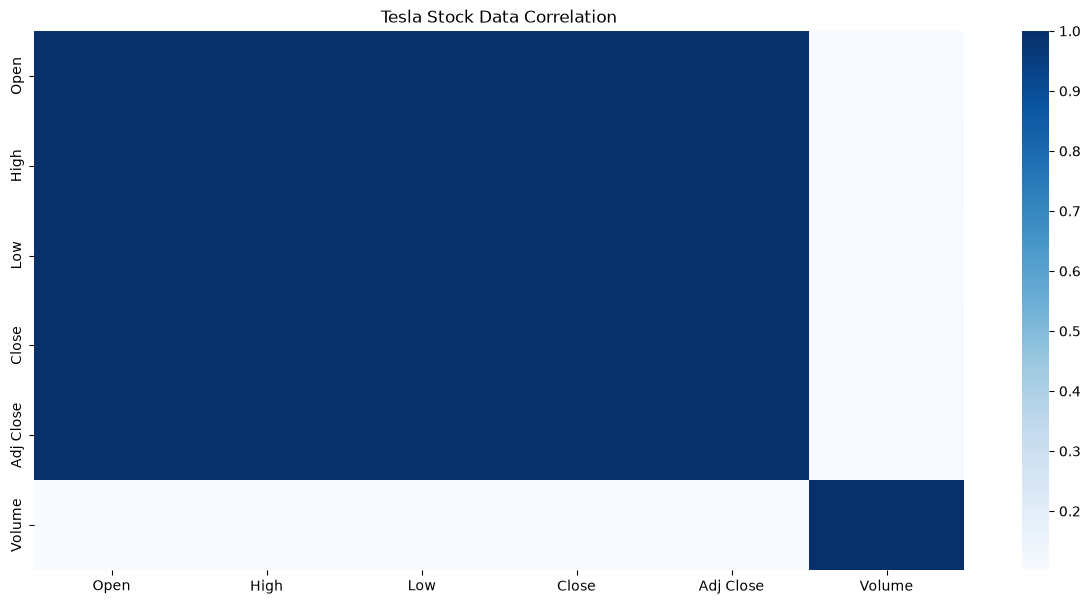

In [5]:
# Correlation Heatmap

plt.figure(figsize=(15,7))

sns.heatmap(df.corr(),cbar=True,cmap="Blues")

plt.title("Tesla Stock Data Correlation")

plt.show()

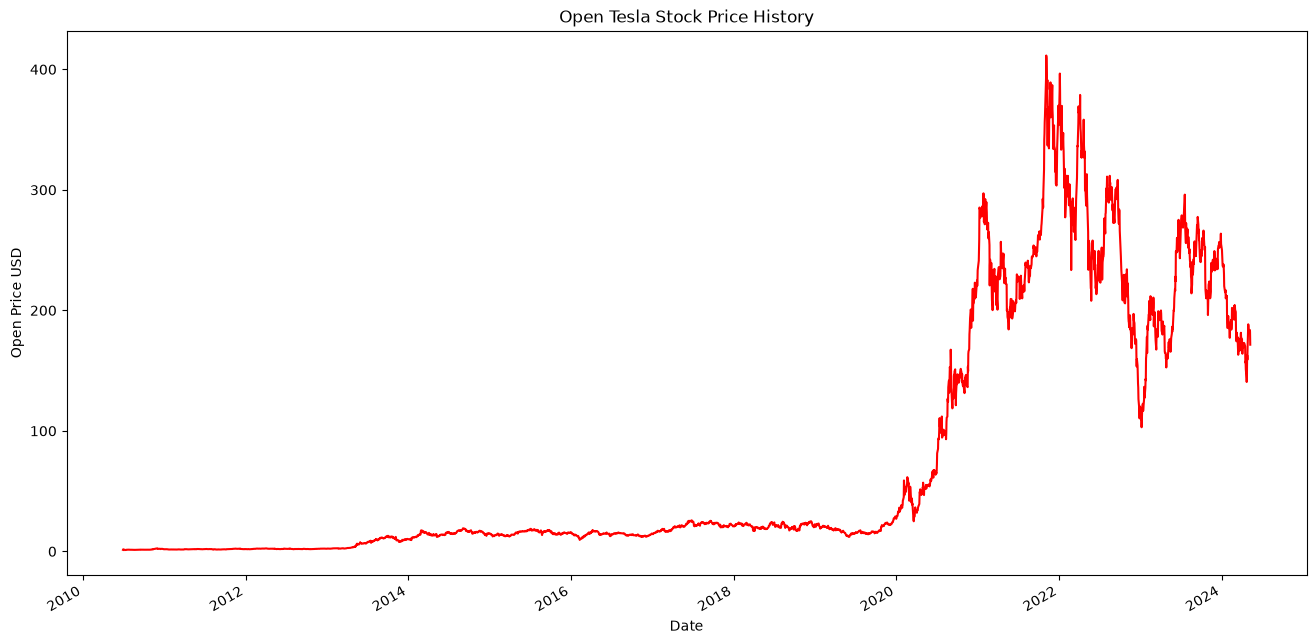

In [6]:
# Tesla Open Price History

df["Open"].plot(figsize=(16,8),color="red")

plt.title("Open Tesla Stock Price History")
plt.xlabel("Date")
plt.ylabel("Open Price USD")

plt.show()

[  1.07599998   1.09333301   1.15933299 ... 396.5166626  409.33334351
 411.47000122] this is the sorted data of open share price


Text(0, 0.5, 'frequency')

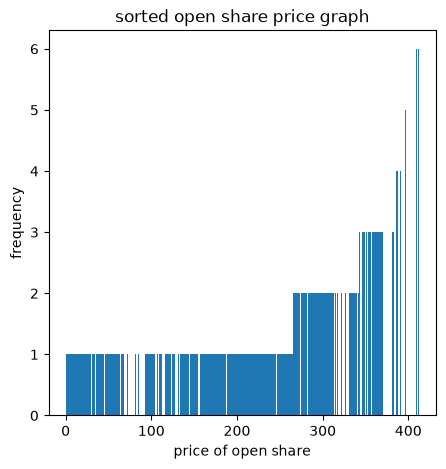

In [7]:
print(np.sort(df['Open']),"this is the sorted data of open share price")
plt.figure(figsize=(5,5))
plt.bar(list(np.sort(df['Open'].value_counts().keys())),list(np.sort(df['Open'].value_counts())))
plt.title("sorted open share price graph")
plt.xlabel("price of open share")
plt.ylabel("frequency")

In [9]:
# Check Missing Values

print(df.isna().any())

Open         False
High         False
Low          False
Close        False
Adj Close    False
Volume       False
dtype: bool


In [10]:
# Select Open Price

dataset = df["Open"]

dataset = pd.DataFrame(dataset)

print(dataset.head())

                Open
Date                
2010-06-29  1.266667
2010-06-30  1.719333
2010-07-01  1.666667
2010-07-02  1.533333
2010-07-06  1.333333


In [11]:
data=dataset.values

data.shape

(3489, 1)

## normalizing data

In [13]:
#  Data Scaling

scaler = MinMaxScaler(feature_range=(0,1))

scaled_data = scaler.fit_transform(data)

print(scaled_data[:5])

[[0.0004646 ]
 [0.0015676 ]
 [0.00143927]
 [0.00111438]
 [0.00062704]]


In [14]:
# Split Data into 75% Training and 25% Testing

train_size = int(len(data) * 0.75)

test_size = len(data) - train_size

print("Train Size:", train_size)
print("Test Size:", test_size)

# Create Training and Testing Data

train_data = scaled_data[:train_size, 0:1]

test_data = scaled_data[train_size-60:, 0:1]

print("Train Data Shape:", train_data.shape)
print("Test Data Shape:", test_data.shape)

Train Size: 2616
Test Size: 873
Train Data Shape: (2616, 1)
Test Data Shape: (933, 1)


In [15]:
#  Create Training Set Using 60 Time Steps

x_train = []
y_train = []

for i in range(60, len(train_data)):
    
    x_train.append(train_data[i-60:i, 0])
    
    y_train.append(train_data[i, 0])

In [16]:
#  Convert Training Data into NumPy Arrays

x_train = np.array(x_train)
y_train = np.array(y_train)

print("X Train Shape:", x_train.shape)
print("Y Train Shape:", y_train.shape)

#  Reshape Training Data for LSTM

x_train = np.reshape(x_train,(x_train.shape[0],x_train.shape[1],1))

print("X Train Shape:", x_train.shape)


X Train Shape: (2556, 60)
Y Train Shape: (2556,)
X Train Shape: (2556, 60, 1)


# building LSTM model

In [17]:
# Create LSTM Model

model = Sequential()

model.add(LSTM(50,return_sequences=True,input_shape=(x_train.shape[1], 1)))

model.add(LSTM(64,return_sequences=False))

model.add(Dense(32))

model.add(Dense(16))

model.add(Dense(1))



C:\Users\acer\anaconda3\envs\tf\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [18]:
# Compile the Model

model.compile(optimizer="adam",loss="mse",metrics=["mean_squared_error"])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        29,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 42,465 (165.88 KB)

 Trainable params: 42,465 (165.88 KB)

 Non-trainable params: 0 (0.00 B)

In [19]:
callbacks = [EarlyStopping(monitor="loss",patience=10,restore_best_weights=True)]

# Train LSTM Model

history = model.fit(x_train,y_train,epochs=100,batch_size=32,callbacks=callbacks)

Epoch 1/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 6s 29ms/step - loss: 2.7159e-04 - mean_squared_error: 2.7159e-04
Epoch 2/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 6.3563e-05 - mean_squared_error: 6.3563e-05
Epoch 3/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 7.3860e-05 - mean_squared_error: 7.3860e-05
Epoch 4/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 5.7806e-05 - mean_squared_error: 5.7806e-05
Epoch 5/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - loss: 6.2991e-05 - mean_squared_error: 6.2991e-05
Epoch 6/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 5.6115e-05 - mean_squared_error: 5.6115e-05
Epoch 7/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 6.2451e-05 - mean_squared_error: 6.2451e-05
Epoch 8/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 5.2119e-05 - mean_squared_error: 5.2119e-05
Epoch 9/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - loss: 6.0591e-05 - mean_squared_error: 6.0591e-05
Epoch 10/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - loss: 4.6

# visualizing performance

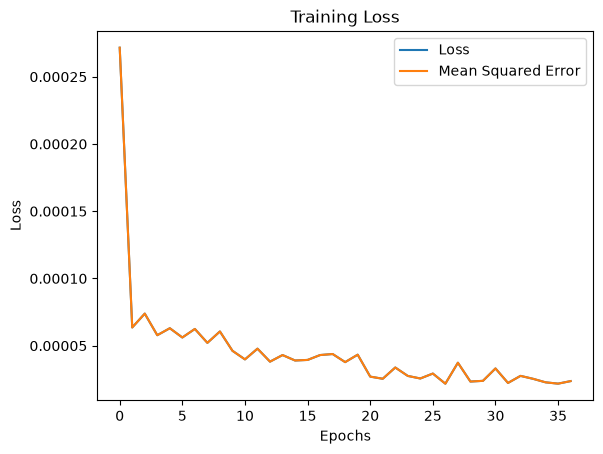

In [21]:
#plt.figure(figsize=(10,5))

plt.plot(
    history.history["loss"],
    label="Loss"
)

plt.plot(
    history.history["mean_squared_error"],
    label="Mean Squared Error"
)

plt.legend()

plt.title("Training Loss")

plt.xlabel("Epochs")
plt.ylabel("Loss")

plt.show()

In [22]:
#  Create Testing Set

x_test = []
y_test = []

for i in range(60, len(test_data)):
    
    x_test.append(test_data[i-60:i, 0])
    
    y_test.append(test_data[i, 0])

x_test = np.array(x_test)
y_test = np.array(y_test)

print("X Test Shape:", x_test.shape)
print("Y Test Shape:", y_test.shape)    

X Test Shape: (873, 60)
Y Test Shape: (873,)


In [23]:
# Reshape Test Data

x_test = np.reshape(x_test,(x_test.shape[0],x_test.shape[1],1))

print("X Test Shape:", x_test.shape)



X Test Shape: (873, 60, 1)


# predicting testing data

In [24]:
predictions = model.predict(x_test)

print(predictions.shape)


# Inverse Scaling

predictions = scaler.inverse_transform(predictions)

y_test = scaler.inverse_transform(y_test.reshape(-1,1))

print("Predictions:")
print(predictions[:5])

print("Actual:")
print(y_test[:5])

28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step
(873, 1)
Predictions:
[[142.41129]
 [152.33589]
 [156.10448]
 [165.42473]
 [171.23166]]
Actual:
[[153.38999939]
 [149.44999695]
 [164.        ]
 [165.99667358]
 [167.83332825]]


In [29]:
#  Calculate RMSE

rmse = np.sqrt(mean_squared_error(y_test,predictions))

print("RMSE:", round(rmse,2))

# Calculate MAE

mae = mean_absolute_error(y_test,predictions)

print("MAE:", round(mae,2))

# Calculate MSE

mse = mean_squared_error(y_test,predictions)

print("MSE:", round(mse,2))

RMSE: 11.98
MAE: 9.52
MSE: 143.53


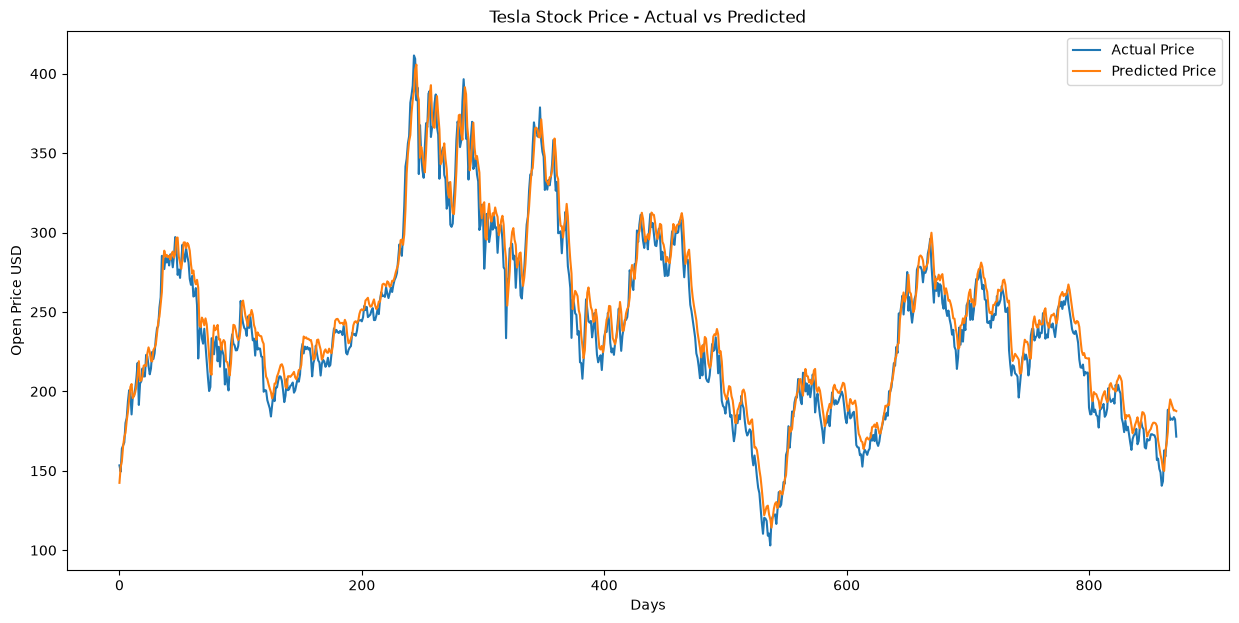

In [31]:
# Actual vs Predicted Price

plt.figure(figsize=(15,7))

plt.plot(y_test,label="Actual Price")


plt.plot(predictions,label="Predicted Price")

plt.title("Tesla Stock Price - Actual vs Predicted")

plt.xlabel("Days")
plt.ylabel("Open Price USD")

plt.legend()

plt.show()

In [32]:
# Actual vs Predicted Values

result = pd.DataFrame({"Actual Price": y_test.flatten(),"Predicted Price": predictions.flatten()})

print(result.head(10))

   Actual Price  Predicted Price
0    153.389999       142.411285
1    149.449997       152.335892
2    164.000000       156.104477
3    165.996674       165.424728
4    167.833328       171.231659
5    180.133331       173.971451
6    183.353333       181.631866
7    193.720001       187.182281
8    200.736664       195.180069
9    199.196671       202.806595


In [33]:
# Save Trained Model

model.save("tesla_stock_model.keras")

print("Model saved successfully!")

Model saved successfully!


In [34]:
# Load Saved Model

from tensorflow.keras.models import load_model

loaded_model = load_model("tesla_stock_model.keras")

print("Model loaded successfully!")

Model loaded successfully!
